# Fake News Detection Using Machine Learning
**Dataset:** ISOT Fake News Dataset (True.csv + Fake.csv)  
**Deployment Target:** Flask API (CPU-optimised)

---
## Group Details
| Name | CPM | MC |
| -- | -- | -- |
| Minoli Perera | 24375 | 108853 |
| Sandagomi Kodikara | 24377 | 108852 |
| Savindi Dissanayake | 24381 | 108798 |

---
## Table of Contents
1. Install & Import Libraries
2. Load Data & Add Labels
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Train / Validation / Test Split (80/10/10)
6. TF-IDF Feature Extraction
7. Model Training
8. Evaluation, Confusion Matrices & ROC Curves
9. Cross-Validation
10. Ablation Study
11. Export Best Model for Flask

---

## Step 1: Install & Import Libraries

In [1]:
# Install required packages (run once) - if you're running on google colab
# ! pip install lightgbm xgboost wordcloud nltk scikit-learn pandas numpy matplotlib seaborn joblib kagglehub tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, string, time, joblib, json, os, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier
from sklearn.calibration     import CalibratedClassifierCV
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Word cloud
from wordcloud import WordCloud

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#e74c3c', '#2ecc71']   # red = Fake, green = Real

# Model tracking
import mlflow
from mlflow import sklearn

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


---
## Step 2: Load Data & Add Labels

In [3]:
# Set the experiment name
mlflow.set_experiment('Fake News Detection')

import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset', output_dir='data/')

print('Loading datasets...')
true_df = pd.read_csv(f'{path}/True.csv')
fake_df = pd.read_csv(f'{path}/Fake.csv')

true_df['label'] = 1   # 1 = Real
fake_df['label'] = 0   # 0 = Fake

news_df = pd.concat([true_df, fake_df], axis=0)
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)  

print(f'Total rows    : {len(news_df):,}')
print(f'Columns       : {list(news_df.columns)}')
print(f'\nClass distribution (0=Fake, 1=Real):')
print(news_df['label'].value_counts())
news_df.head(3)

2026/05/05 01:41:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/05 01:41:12 INFO mlflow.store.db.utils: Updating database tables
2026/05/05 01:41:13 INFO mlflow.tracking.fluent: Experiment with name 'Fake News Detection' does not exist. Creating a new experiment.


100%|██████████| 41.0M/41.0M [00:15<00:00, 2.80MB/s]

Extracting files...


Loading datasets...
Total rows    : 44,898
Columns       : ['title', 'text', 'subject', 'date', 'label']

Class distribution (0=Fake, 1=Real):
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0


---
## Step 3: Exploratory Data Analysis (EDA)
### 3a. Class Distribution

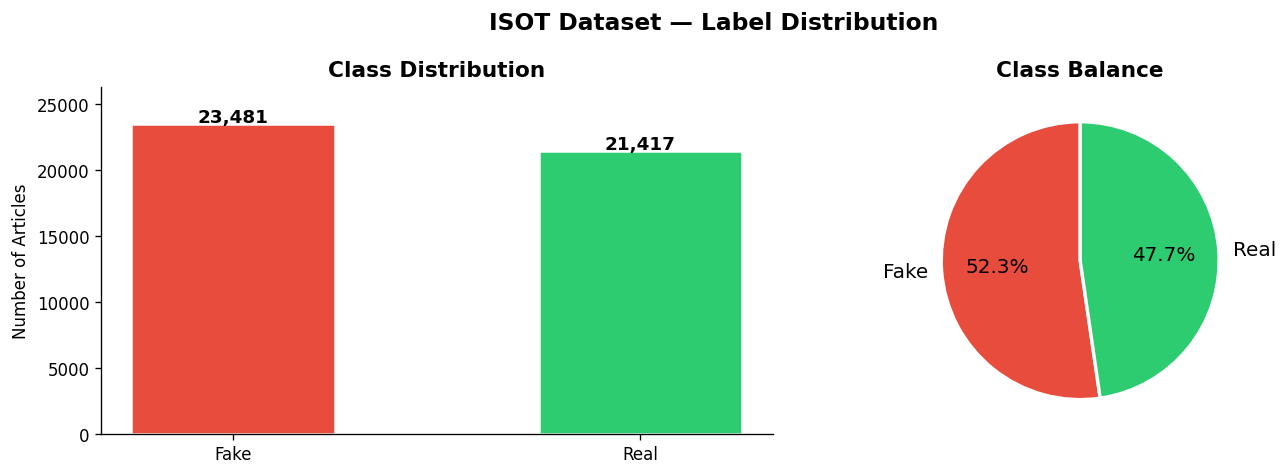

Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.


In [4]:
counts = news_df['label'].value_counts().sort_index()  # [Fake, Real]
labels = ['Fake', 'Real']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
axes[0].set_ylim(0, max(counts.values) * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('ISOT Dataset — Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.')

### 3b. Article Length Distribution

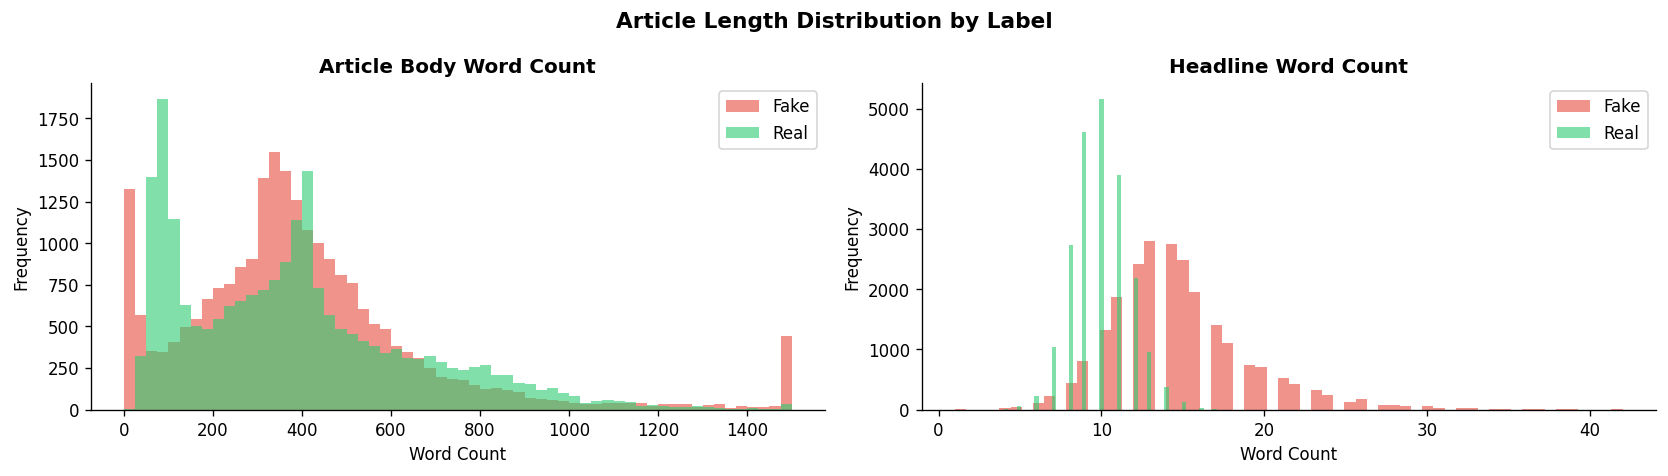


Body length statistics by label:
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


In [5]:
news_df['text_len']  = news_df['text'].str.split().str.len()
news_df['title_len'] = news_df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (col, title) in enumerate([('text_len',  'Article Body Word Count'),
                                    ('title_len', 'Headline Word Count')]):
    for label_val, color, name in zip([0, 1], PALETTE, ['Fake', 'Real']):
        axes[i].hist(
            news_df[news_df['label'] == label_val][col].clip(upper=1500),
            bins=60, alpha=0.6, color=color, label=name, edgecolor='none')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Article Length Distribution by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBody length statistics by label:')
print(news_df.groupby('label')['text_len'].describe()
      .round(1).rename(index={0: 'Fake', 1: 'Real'}))

### 3c. Subject Category Distribution

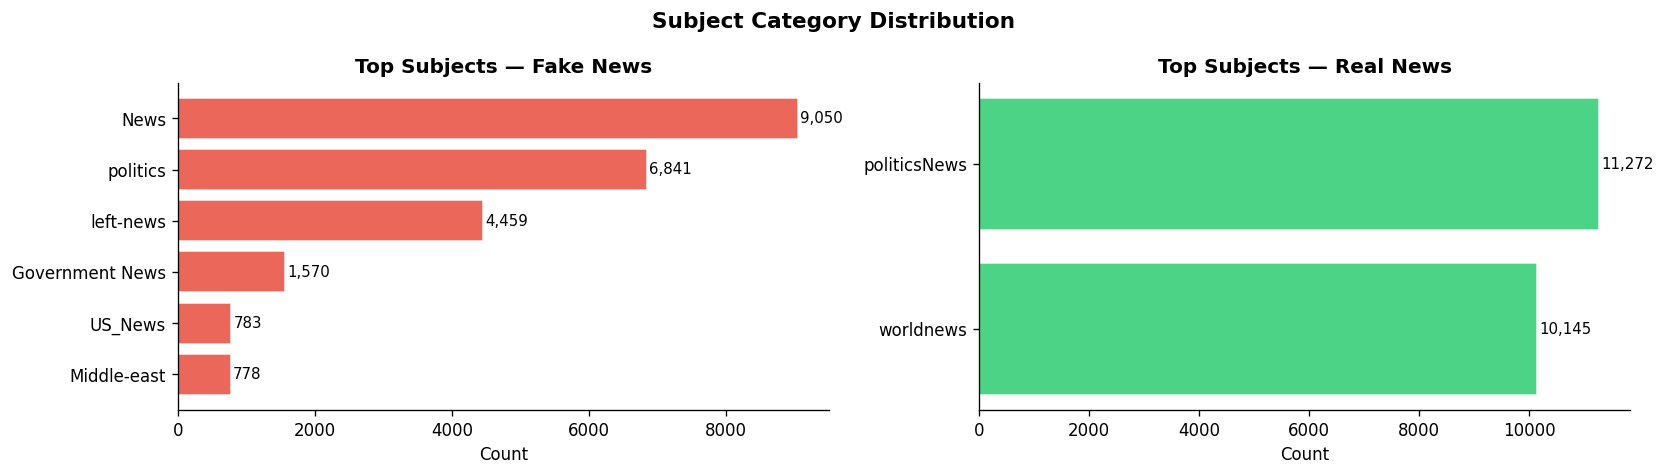

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label_val, title, color) in zip(
        axes, [(0, 'Fake News', '#e74c3c'), (1, 'Real News', '#2ecc71')]):
    cnts = news_df[news_df['label'] == label_val]['subject'].value_counts().head(8)
    ax.barh(cnts.index[::-1], cnts.values[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top Subjects — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(cnts.values[::-1]):
        ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Subject Category Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Word Clouds

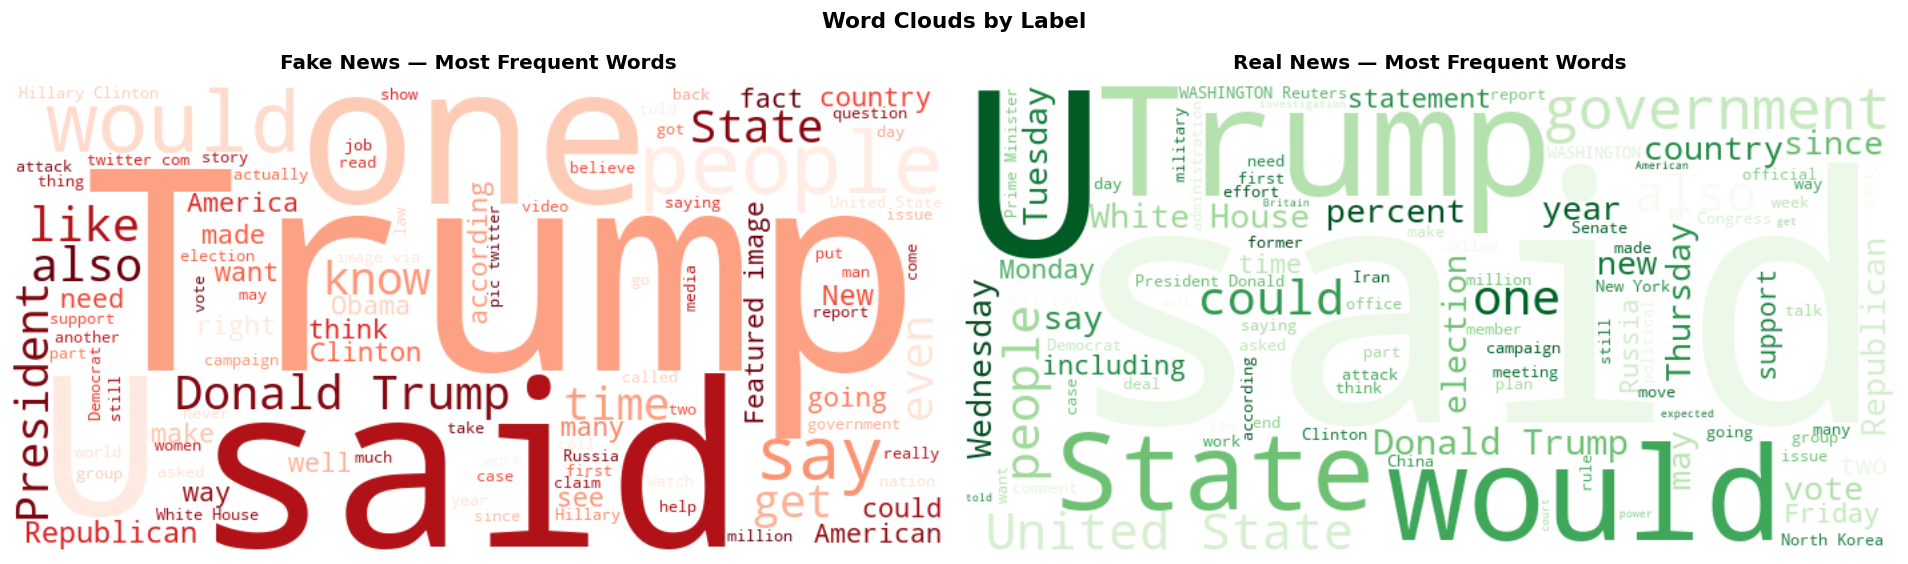

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sw = set(stopwords.words('english'))

for ax, (label_val, title, cmap) in zip(axes, [
        (0, 'Fake News — Most Frequent Words', 'Reds'),
        (1, 'Real News — Most Frequent Words', 'Greens')]):
    sample_size = min(3000, (news_df['label'] == label_val).sum())
    text = ' '.join(
        news_df[news_df['label'] == label_val]['text']
        .dropna().sample(sample_size, random_state=42)
    )
    wc = WordCloud(width=700, height=350, background_color='white',
                   max_words=100, colormap=cmap, stopwords=sw).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Text Preprocessing
> **FIX applied:** Added lemmatization. Reuters dateline stripping retained to prevent data leakage.

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    text = str(text).lower()

    # ── Data-leakage fix ───────────────────────────────────────────────────────
    # Real articles often start with "CITY (Reuters) -"; remove this source tag
    # so the model learns content patterns, not publisher identity.
    text = re.sub(r'\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'\breuters\b', '', text)
    # ──────────────────────────────────────────────────────────────────────────

    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # Remove URLs
    text = re.sub(r'<.*?>', '', text)                            # Remove HTML
    text = re.sub(r"won't", 'will not', text)                   # Expand contractions
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"n't",   ' not', text)
    text = re.sub(r"'re",   ' are', text)
    text = re.sub(r"'ve",   ' have', text)
    text = re.sub(r"'ll",   ' will', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                    # Normalise whitespace

    # Tokenise → remove stopwords → lemmatize  ← NEW
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

# Combine title + text for richer signal, then clean
print('Combining title + text and applying preprocessing...')
print('(This takes ~1-2 minutes on Colab)')
t0 = time.time()

news_df['full_text']  = news_df['title'] + ' ' + news_df['text']
news_df['clean_text'] = news_df['full_text'].apply(clean_text)

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'\nSample before: {news_df["full_text"].iloc[0][:120]}')
print(f'Sample after : {news_df["clean_text"].iloc[0][:120]}')

Combining title + text and applying preprocessing...
(This takes ~1-2 minutes on Colab)
Done in 34.2s ✓

Sample before:  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and
Sample after : breaking gop chairman grassley enough demand trump testimony donald trump white house chaos trying cover russia problem 


---
## Step 5: Train / Validation / Test Split (80 / 10 / 10)
> **FIX applied:** Changed from a single 70/30 split to the 80/10/10 split specified in the proposal.
> The vectorizer is fitted **only on the training set** to prevent data leakage.

In [9]:
X = news_df['clean_text']
y = news_df['label']

# Step 1: split off 20% as temp set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Step 2: split temp equally into val and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):,}  samples  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}  samples  ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nClass balance in train — Fake: {sum(y_train==0):,}  Real: {sum(y_train==1):,}')

Train : 35,918 samples  (80.0%)
Val   : 4,490  samples  (10.0%)
Test  : 4,490  samples  (10.0%)

Class balance in train — Fake: 18,785  Real: 17,133


---
## Step 6: TF-IDF Feature Extraction
> **FIX applied:** `max_features` raised from 10,000 → 50,000 for better coverage of the vocabulary.

Fitting TF-IDF on training data only...
Done in 25.5s ✓
Vocabulary size : 50,000
Train matrix    : (35918, 50000)


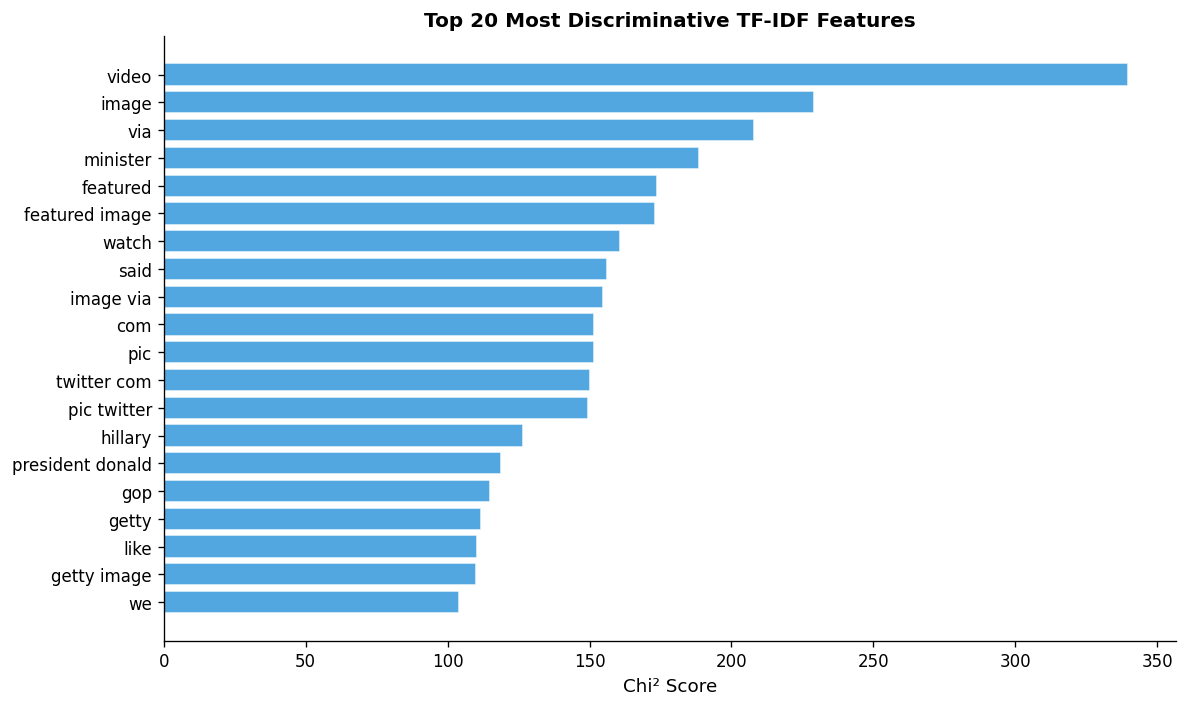

In [10]:
# Fit ONLY on training data — never on val/test
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams + bigrams
    max_features=50_000,    # FIX: raised from 10k for better vocab coverage
    sublinear_tf=True,      # log(1+tf) dampens very frequent terms
    min_df=3,               # ignore terms that appear in < 3 docs
    max_df=0.90,            # ignore terms in > 90% of docs
    strip_accents='unicode' # normalize accents for better matching (e.g. café → cafe)
)

print('Fitting TF-IDF on training data only...')
t0 = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)   # fit + transform
X_val_tfidf   = tfidf_vectorizer.transform(X_val)         # transform only
X_test_tfidf  = tfidf_vectorizer.transform(X_test)        # transform only

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'Train matrix    : {X_train_tfidf.shape}')

# Top discriminative features
chi2_scores, _ = chi2(X_train_tfidf, y_train)
feat_names     = tfidf_vectorizer.get_feature_names_out()
top_idx        = np.argsort(chi2_scores)[::-1][:20]
top_feats      = [(feat_names[i], chi2_scores[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
names, scores = zip(*top_feats[::-1])
ax.barh(names, scores, color='#3498db', alpha=0.85, edgecolor='white')
ax.set_xlabel('Chi² Score', fontsize=11)
ax.set_title('Top 20 Most Discriminative TF-IDF Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Model Training

In [11]:
# Shared evaluation helper
def evaluate(model, X_vec, y_true, flavor="sklearn"):
    # 1. Check if the model is a TensorFlow/Keras model
    if flavor == 'tensorflow':
        y_prob = model.predict(X_vec, verbose=0).flatten() # Keras predict() returns 2D probabilities (e.g., [[0.9], [0.1]])
        y_pred = (y_prob > 0.5).astype(int) # Convert probabilities to discrete 0 or 1 classes for accuracy/f1
    
    # 2. Otherwise, treat it as a standard Scikit-Learn model
    else:
        y_pred = model.predict(X_vec)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_vec)[:, 1]
        
        else:
            y_prob = model.decision_function(X_vec)
            
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall'   : recall_score(y_true, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

In [12]:
# Tracking models
def train_and_log_models(model_class, model_name, X_train, y_train, X_val, y_val, flavor = 'sklearn', tokenizer = None, **params):
    with mlflow.start_run(run_name = model_name):
        # 1. Initialize the model with the optional parameters
        model = model_class(**params)
        model = model_class(**params)

        # 2. Log hyperparameters automatically
        mlflow.log_params(params)

        # 3. Train the model
        t0 = time.time()
        if flavor == 'tensorflow':
            model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 3, batch_size = 64, verbose=1)

        else:
            model.fit(X_train, y_train)

        train_time = time.time() - t0

        # 4. Evaluate and log metrics
        results = evaluate(model, X_val, y_val, flavor = flavor)

        mlflow.log_metrics({
            "accuracy": results['Accuracy'],
            "precision": results['Precision'],
            "recall": results['Recall'],
            "f1_macro": results['F1 (macro)'],
            "roc_auc": results['ROC-AUC'],
            "train_time": train_time
        })

        y_pred = results['y_pred']

        # 5. Log a plot as artifact
        fig, ax = plt.subplots(figsize = (8, 5))
        ax.scatter(y_val, y_pred, alpha = 0.4, edgecolors = 'k', s = 20)
        ax.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--',
            lw = 2
        )
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Actual vs Predicted - {model_name}')
        plt.tight_layout()
        plt.savefig('actual-vs-predicted.png', dpi = 120)
        plt.close()

        mlflow.log_artifact('actual-vs-predicted.png')

        # 6. Log the model
        if flavor == 'tensorflow':
            mlflow.tensorflow.log_model(
                model,
                name = 'model',
                registered_model_name=f'FakeNewsClassification_{model_name}'
            )

            if tokenizer:
                # Save tokenizer explicitly for DL models
                with open('tokenizer.json', 'w') as f:
                    f.write(tokenizer.to_json())
                mlflow.log_artifact('tokenizer.json')
        
        else:
            mlflow.sklearn.log_model(
                model,
                name = 'model',
                registered_model_name = f'FakeNewsClassification_{model_name}'
            )

        # Fixed f-string quote issue inside dictionary access
        print(f'\n[{model_name}] Accuracy: {results['Accuracy']} | Precision: {results['Precision']} | Recall: {results['Recall']} | F1_Macro: {results['F1 (macro)']} | ROC-AUC: {results['ROC-AUC']}')

### 7a. Logistic Regression

In [13]:
print('Training Logistic Regression...')
log_model = train_and_log_models(
    LogisticRegression,
    'LogisticRegression',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1
)

Training Logistic Regression...


2026/05/05 01:42:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[LogisticRegression] Accuracy: 0.988641425389755 | Precision: 0.9884245892485651 | Recall: 0.9888939391770337 | F1_Macro: 0.9886233441585202 | ROC-AUC: 0.9990000827133807


Successfully registered model 'FakeNewsClassification_LogisticRegression'.
Created version '1' of model 'FakeNewsClassification_LogisticRegression'.


### 7b. Naive Bayes

In [14]:
print('Training Naive Bayes...')
nb_model = train_and_log_models(
    MultinomialNB,
    'NaiveBayes',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    alpha=0.1
)

2026/05/05 01:42:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Naive Bayes...

[NaiveBayes] Accuracy: 0.9623608017817372 | Precision: 0.9622561518083905 | Recall: 0.9623121253044091 | F1_Macro: 0.9622837063931605 | ROC-AUC: 0.991852930837298


Successfully registered model 'FakeNewsClassification_NaiveBayes'.
Created version '1' of model 'FakeNewsClassification_NaiveBayes'.


### 7c. Linear SVM

In [15]:
print('Training Linear SVM...')

# Wrap with CalibratedClassifierCV so we get predict_proba for ROC curve
svm_base  = LinearSVC(random_state=42, dual=False, max_iter=2000)
svm_model = train_and_log_models(
    CalibratedClassifierCV,
    'LinearSVM',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    estimator = svm_base,
    cv=3
)


Training Linear SVM...


2026/05/05 01:42:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[LinearSVM] Accuracy: 0.9955456570155902 | Precision: 0.9955362610688796 | Recall: 0.9955362610688796 | F1_Macro: 0.9955362610688796 | ROC-AUC: 0.9997860586596932


Successfully registered model 'FakeNewsClassification_LinearSVM'.
Created version '1' of model 'FakeNewsClassification_LinearSVM'.


### 7d. Random Forest

In [16]:
print('Training Random Forest...')
rf_model = train_and_log_models(
    RandomForestClassifier,
    'RandomForestClassifier',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

Training Random Forest...


2026/05/05 01:42:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[RandomForestClassifier] Accuracy: 0.9899777282850779 | Precision: 0.9898453375199352 | Recall: 0.990089704251945 | F1_Macro: 0.9899591762618527 | ROC-AUC: 0.9993132403444058


Successfully registered model 'FakeNewsClassification_RandomForestClassifier'.
Created version '1' of model 'FakeNewsClassification_RandomForestClassifier'.


### 7e. XGBoost

In [17]:
print('Training XGBoost...')
xgb_model = train_and_log_models(
    xgb.XGBClassifier,
    'XGBoost',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    eval_metric='logloss', 
    random_state=42, 
    n_jobs=-1
)

Training XGBoost...


2026/05/05 01:44:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[XGBoost] Accuracy: 0.9930957683741648 | Precision: 0.9930338832475453 | Recall: 0.993132403444058 | F1_Macro: 0.9930819044559265 | ROC-AUC: 0.9997154739238114


Successfully registered model 'FakeNewsClassification_XGBoost'.
Created version '1' of model 'FakeNewsClassification_XGBoost'.


### 7f. 1D CNN (Neural Architecture)

In [18]:
print('Preparing tokenizer for 1D CNN...')
MAX_WORDS = 10000
MAX_LEN   = 500

# 1. Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)   # fit on train only

# 2. Convert text to sequences and pad them
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

# 3. Building 1D CNN
print('Building 1D CNN architecture...')
def build_1d_cnn(max_words = 10000, max_len = 500, filters = 64, kernel_size = 5):
    model = Sequential([
        Embedding(input_dim = max_words, output_dim=50, input_length = max_len),
        Conv1D(filters = filters, kernel_size = kernel_size, activation='relu'),
        GlobalMaxPooling1D(), 
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 4. Model tracking
dl_model = train_and_log_models(
    build_1d_cnn,
    '1DCNNArchitecture',
    X_train_seq,
    y_train,
    X_val_seq,
    y_val,
    flavor = 'tensorflow',
    tokenizer = tokenizer,
    max_words = MAX_WORDS,
    max_len = MAX_LEN,
    filters = 64,
    kernel_size = 5
)

Preparing tokenizer for 1D CNN...
Building 1D CNN architecture...
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9283 - loss: 0.1659 - val_accuracy: 0.9904 - val_loss: 0.0319
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9949 - loss: 0.0190 - val_accuracy: 0.9944 - val_loss: 0.0192
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9991 - loss: 0.0046 - val_accuracy: 0.9940 - val_loss: 0.0205


2026/05/05 01:45:00 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
Successfully registered model 'FakeNewsClassification_1DCNNArchitecture'.
Created version '1' of model 'FakeNewsClassification_1DCNNArchitecture'.



[1DCNNArchitecture] Accuracy: 0.9939866369710467 | Precision: 0.9939088325555592 | Recall: 0.9940456307451999 | F1_Macro: 0.9939748015195846 | ROC-AUC: 0.9998240352359001


---
## Step 8: Evaluation, Confusion Matrices & ROC Curves
### 8a. Summary Table

In [ ]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC-AUC', 'train_time']
summary_df  = pd.DataFrame(
    {name: {m: v for m, v in res.items() if m in metric_cols}
     for name, res in val_results.items()}
).T

summary_df['train_time'] = summary_df['train_time'].round(1).astype(str) + 's'
for col in ['Accuracy','Precision','Recall','F1 (macro)','ROC-AUC']:
    summary_df[col] = summary_df[col].astype(float).round(4)

print('=== Validation Set — All Model Metrics ===')
display(summary_df.sort_values('F1 (macro)', ascending=False))

### 8b. Full Metric Comparison Bar Chart

In [ ]:
plot_df   = summary_df[['Accuracy','Precision','Recall','F1 (macro)','ROC-AUC']].astype(float)
plot_df   = plot_df.sort_values('F1 (macro)')
x         = np.arange(len(plot_df))
width     = 0.15
colors    = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, color) in enumerate(zip(plot_df.columns, colors)):
    bars = ax.bar(x + i*width, plot_df[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_title('All Models — All Metrics (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

### 8c. ROC Curves for All Models

In [ ]:
roc_colors = ['#3498db','#95a5a6','#e74c3c','#f39c12','#9b59b6','#2ecc71']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, res), color in zip(val_results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

### 8d. Confusion Matrices

In [ ]:
model_names_list = list(val_results.keys())
n = len(model_names_list)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4.5))
axes = axes.flatten()

for i, name in enumerate(model_names_list):
    cm   = confusion_matrix(y_val, val_results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=11, fontweight='bold')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9: Cross-Validation
> **FIX applied:** 5-fold Stratified Cross-Validation added as required by the proposal.

In [ ]:
# Combine train + val for CV (test set remains untouched)
import scipy.sparse as sp
X_tv     = sp.vstack([X_train_tfidf, X_val_tfidf])
y_tv     = pd.concat([y_train, y_val]).reset_index(drop=True)

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': log_model,
    'Naive Bayes'        : nb_model,
    'Linear SVM'         : svm_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}

cv_results = {}
print('Running 5-fold cross-validation (CNN excluded — too slow for CV on CPU)...')
for name, model in cv_models.items():
    t0 = time.time()
    scores = cross_val_score(model, X_tv, y_tv, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<22} F1: {scores.mean():.4f} ± {scores.std():.4f}  ({time.time()-t0:.1f}s)')

In [ ]:
# Plot CV results
fig, ax = plt.subplots(figsize=(12, 5))
cv_colors = ['#3498db','#95a5a6','#e74c3c','#f39c12','#9b59b6']

x_pos = np.arange(len(cv_results))
for xi, (name, scores) in enumerate(cv_results.items()):
    color = cv_colors[xi]
    fold_x = xi + np.linspace(-0.2, 0.2, 5)
    ax.scatter(fold_x, scores, color=color, s=60, zorder=3)
    ax.hlines(scores.mean(), xi-0.25, xi+0.25, color=color, lw=3)
    ax.text(xi, scores.mean() - 0.004, f'{scores.mean():.4f}',
            ha='center', va='top', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(list(cv_results.keys()), fontsize=10)
ax.set_ylabel('F1-macro per fold', fontsize=11)
ax.set_title('5-Fold Cross-Validation F1 Scores', fontsize=13, fontweight='bold')
ax.set_ylim(0.93, 1.005)
plt.tight_layout()
plt.show()

---
## Step 10: Ablation Study
> **FIX applied:** Added ablation study to measure the contribution of different feature configurations,
> as required by the proposal.

We test the **best classical model (Linear SVM)** under 4 feature configurations:
1. Title only
2. Text body only
3. Title + Text *(current setup)*
4. Title + Text + Subject (one-hot encoded)

In [ ]:
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder

ablation_results = {}

def run_ablation(X_tr, X_v, name):
    """Fit a fresh Linear SVM on given feature matrix and evaluate on val."""
    base = LinearSVC(random_state=42, dual=False, max_iter=2000)
    clf  = CalibratedClassifierCV(base, cv=3)
    clf.fit(X_tr, y_train)
    res = evaluate(clf, X_v, y_val)
    ablation_results[name] = res
    print(f'  {name:<35} F1={res["F1 (macro)"]:.4f}  AUC={res["ROC-AUC"]:.4f}')

print('Running ablation study (Linear SVM)...\n')

# Config 1: Title only
v1 = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, min_df=3)
run_ablation(v1.fit_transform(news_df.loc[X_train.index, 'title'].fillna('')),
             v1.transform(news_df.loc[X_val.index,   'title'].fillna('')),
             'Title only')

# Config 2: Text body only
v2 = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, min_df=3)
run_ablation(v2.fit_transform(news_df.loc[X_train.index, 'clean_text'].fillna('')),
             v2.transform(news_df.loc[X_val.index,   'clean_text'].fillna('')),
             'Text body only')

# Config 3: Title + Text (baseline, already have these)
ablation_results['Title + Text (baseline)'] = val_results['Linear SVM']
print(f'  {"Title + Text (baseline)":<35} '
      f'F1={val_results["Linear SVM"]["F1 (macro)"]:.4f}  '
      f'AUC={val_results["Linear SVM"]["ROC-AUC"]:.4f}')

# Config 4: Title + Text + Subject (one-hot)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
subj_train = ohe.fit_transform(news_df.loc[X_train.index, 'subject'].values.reshape(-1,1))
subj_val   = ohe.transform(news_df.loc[X_val.index,   'subject'].values.reshape(-1,1))
run_ablation(hstack([X_train_tfidf, subj_train]),
             hstack([X_val_tfidf,   subj_val]),
             'Title + Text + Subject')

In [ ]:
# Plot ablation
abl_names  = list(ablation_results.keys())
abl_f1     = [ablation_results[n]['F1 (macro)'] for n in abl_names]
abl_auc    = [ablation_results[n]['ROC-AUC']    for n in abl_names]

x      = np.arange(len(abl_names))
width  = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, abl_f1,  width, label='F1 (macro)', color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, abl_auc, width, label='ROC-AUC',    color='#e74c3c', alpha=0.85)
ax.bar_label(b1, fmt='%.4f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(abl_names, fontsize=10)
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — Feature Contribution (Linear SVM)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 11: Final Test Set Evaluation & Export
### 11a. Select best model, evaluate on held-out test set

In [ ]:
# Pick best model by validation F1
best_name  = max(val_results, key=lambda k: val_results[k]['F1 (macro)'])
best_model = model_store[best_name]
print(f'Best model (by val F1): {best_name}')

# Use appropriate test features
X_test_eval = X_test_seq if best_name == '1D CNN' else X_test_tfidf

if best_name == '1D CNN':
    test_prob = best_model.predict(X_test_eval).flatten()
    test_pred = (test_prob > 0.5).astype(int)
    test_res  = {
        'Accuracy'  : accuracy_score(y_test, test_pred),
        'Precision' : precision_score(y_test, test_pred, average='macro'),
        'Recall'    : recall_score(y_test, test_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, test_pred, average='macro'),
        'ROC-AUC'   : roc_auc_score(y_test, test_prob),
        'y_pred'    : test_pred,
        'y_prob'    : test_prob,
    }
else:
    test_res = evaluate(best_model, X_test_tfidf, y_test)
    test_pred = test_res['y_pred']

print(f'\n=== FINAL TEST SET RESULTS ({best_name}) ===')
for k, v in test_res.items():
    if k not in ('y_pred','y_prob'):
        print(f'  {k:<15}: {v:.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, test_pred, target_names=['Fake','Real']))

### 11b. Final Confusion Matrix & Prediction Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm   = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (Test Set)', fontsize=11, fontweight='bold')

# Probability distribution
for label_val, color, name in zip([0,1], PALETTE, ['Fake','Real']):
    mask = (y_test == label_val).values
    axes[1].hist(test_res['y_prob'][mask], bins=50, alpha=0.6,
                 color=color, label=name, density=True)
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability (Real)')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction Score Distribution\nby True Label (Test Set)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 11c. Export Model for Flask Deployment

In [ ]:
# ── Portable export — works locally AND on Colab ───────────────────────────────
os.makedirs('models', exist_ok=True)

# Always export the best classical (TF-IDF based) model for Flask
# Even if CNN won, we deploy the fastest classical model for CPU inference
classical_models = {k: v for k, v in val_results.items() if k != '1D CNN'}
best_classical   = max(classical_models, key=lambda k: classical_models[k]['F1 (macro)'])
deploy_model     = model_store[best_classical]

joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(deploy_model,     'models/best_model.pkl')

# Save metadata
meta = {
    'deployed_model'  : best_classical,
    'val_f1_macro'    : round(classical_models[best_classical]['F1 (macro)'], 6),
    'val_roc_auc'     : round(classical_models[best_classical]['ROC-AUC'], 6),
    'test_f1_macro'   : round(test_res['F1 (macro)'], 6),
    'test_accuracy'   : round(test_res['Accuracy'], 6),
    'vocab_size'      : len(tfidf_vectorizer.vocabulary_),
    'ngram_range'     : '(1,2)',
    'max_features'    : 50000,
    'train_samples'   : len(X_train),
    'test_samples'    : len(X_test),
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== Files saved to ./models/ ===')
print('  tfidf_vectorizer.pkl  — TF-IDF vectorizer')
print('  best_model.pkl        — Trained classifier')
print('  model_metadata.json   — Run metadata')
print(f'\nDeployed model : {best_classical}')
print(f'Val F1         : {meta["val_f1_macro"]}')
print(f'Test F1        : {meta["test_f1_macro"]}')
print(f'Test Accuracy  : {meta["test_accuracy"]}')

# If running on Colab, also trigger download
try:
    from google.colab import files
    print('\nColab detected — downloading model files...')
    files.download('models/tfidf_vectorizer.pkl')
    files.download('models/best_model.pkl')
except ImportError:
    print('\nLocal environment — files saved to ./models/')

---
## Quick Inference Test *(simulates Flask usage)*

In [ ]:
def predict_article(title: str, text: str) -> dict:
    """Exactly what the Flask /predict route will call."""
    combined = clean_text(title + ' ' + text)
    vec      = tfidf_vectorizer.transform([combined])
    pred     = deploy_model.predict(vec)[0]
    prob     = deploy_model.predict_proba(vec)[0]
    return {
        'label'      : 'REAL' if pred == 1 else 'FAKE',
        'confidence' : round(float(max(prob)) * 100, 2),
        'fake_prob'  : round(float(prob[0]) * 100, 2),
        'real_prob'  : round(float(prob[1]) * 100, 2),
    }

sample_real = news_df[news_df['label'] == 1].iloc[10]
sample_fake = news_df[news_df['label'] == 0].iloc[10]

r1 = predict_article(sample_real['title'], sample_real['text'])
r2 = predict_article(sample_fake['title'], sample_fake['text'])

print('=== Inference Test ===')
print(f'\nActual: REAL  | Predicted: {r1["label"]}  | Confidence: {r1["confidence"]}%')
print(f'Title : {sample_real["title"][:90]}')
print(f'\nActual: FAKE  | Predicted: {r2["label"]}  | Confidence: {r2["confidence"]}%')
print(f'Title : {sample_fake["title"][:90]}')